# 4. spaCy I — NER i detecció de patrons

Tractament de Dades Textuals i Codificades — Eixample Clínic, 2026

Pol Pastells, ppastells@eixampleclinic.es

In [ ]:
# Instal·lació (executeu només una vegada)
! pip install ipython==7.23.1 -q
! pip install "spacy<3.8.0,>=3.7.4"  -q
! python -m spacy download ca_core_news_sm
! python -m spacy download es_core_news_sm
! python -m spacy download en_core_web_sm

Cada model d'spaCy s'ha de descarregar per separat.

Comencem amb el model petit per català (acabat amb "sm"), també n'hi ha un de mitjà i un de gran. Podeu buscar models per altres llengües: 
https://spacy.io/usage/models

Els models d'spaCy fan un conjunt de tasques una rere l'altra (pipe "canonada").

In [ ]:
import spacy
from spacy import displacy
from spacy.matcher import Matcher
from spacy.pipeline import EntityRuler

# Model català petit
nlp = spacy.load("ca_core_news_sm")
print("Pipeline del model català:", nlp.pipe_names)

---
## 0. Pipeline bàsica: tokenització, PoS, dependències

Quan feu servir `nlp(text)`, spaCy executa en seqüència tots els components del pipeline:

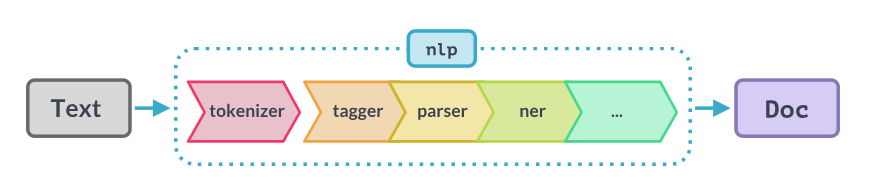

Cada component afegeix informació als tokens o al document.

In [ ]:
# aplicant nlp a una frase obtenim un Doc d'spacy
frase = "Les Maries va veure en Joan al parc amb un telescopi."
doc = nlp(frase)
print("DOC:", doc, type(doc))

# Si iterem Doc podem veure diferents propietats de cada token
print("\nTOKENS     LEMES      POS          ---- DEPENDÈNCIES ----     INFO MORFOLÒGICA")
for token in doc:
    print(
        f"{token.text:10} {token.lemma_:10} POS={token.pos_:8} DEP={token.dep_:6} HEAD={token.head.text:10} {token.morph}"
    )

In [ ]:
# El PoS tagger de NLTK ens retornava el següent
pos = [(w.lemma_, w.pos_) for w in doc]
pos

## 1. Stopwords, Sintagmes Nominals, subjecte i objecte

Els models d'spaCy porten stopwords incorporats, diferents dels de NLTK.

In [ ]:
print(nlp.Defaults.stop_words)

In [ ]:
# Podem veure si cada token és un stopword
# ja estan incorporats al model
for token in doc:
    print(f"{token.text:10} {token.is_stop}")

In [ ]:
[token.text for token in doc if not token.is_stop]

In [ ]:
# I podem modificar-los així
nlp.vocab["pluja"].is_stop = True
nlp.vocab["la"].is_stop = False
frase2 = nlp("la pluja em mulla")
for token in frase2:
    print(f"{token.text:10} {token.is_stop}")

In [ ]:
# Sintagmes Nominals
frases = "La Rosa menja un entrepà gran de fuet de Vic. L'Oriol rega les plantes."
doc2 = nlp(frases)

print("--- Sintagmes Nominals ---")
for chunk in doc2.noun_chunks:
    print(f"  SN: {chunk.text}")

In [ ]:
# Subjectes i objectes
print("\n--- Subjectes i Objectes ---")
for token in doc2:
    if token.dep_ in ("nsubj", "nsubj:pass"):
        print(f"  SUBJECTE: {token.text}")
    if token.dep_ in ("obj", "dobj", "iobj"):
        print(f"  OBJECTE:  {token.text}")

## 2. Named Entity Recognition (NER)

El Reconeixement d'Entitats Nombrades, és una tasca de PLN que consisteix a **identificar i classificar** mencions de noms al text en categories predefinides:

| Categoria | Descripció | Exemple |
|-----------|------------|---------|
| `PER` | Persona | *Albert Einstein* |
| `ORG` | Organització | *Universitat de Barcelona* |
| `LOC` | Localització | *Barcelona*, *el Mediterrani* |
| `MISC` | Miscel·lània | *Jocs Olímpics*, *iPhone* |
| `DATE` | Data/temps | *el 23 d'abril*, *1995* |
| `MONEY` | Diners | *500 euros* |

> Cada model pot tenir el seu conjunt de categories. Els models biomèdics en tenen de molt específiques.


### L'esquema BIO (Begin – Inside – Outside)

Els models de NER treballen a nivell de **token**. Com saben que dos tokens consecutius formen la mateixa entitat?

S'usa l'etiqueta **BIO** (o similar):

- **B-XXX** → primer token d'una entitat de tipus XXX  
- **I-XXX** → token interior d'una entitat de tipus XXX  
- **O** → token que no pertany a cap entitat  

#### Exemple:

```
Token          Etiqueta BIO
─────────────────────────────
Albert         B-PER
Einstein       I-PER
va             O
néixer         O
a              O
Ulm            B-LOC
el             O
1879           B-DATE
.              O
```

#### Per què és necessari?

Sense BIO, si tenim dos noms seguits, no sabríem si és una entitat composta o dues d'independents:  
`Joan Miró` (una PER) vs `Joan` (PER) + `Miró` (PER).


### Com s'entrena un model NER?

```
Text anotat amb BIO  →  Model  →  Predicció d'etiquetes BIO  →  Entitats
```

Els models aprenen a predir les etiquetes BIO a partir d'exemples anotats manualment.

**spaCy** inclou el NER com a component del pipeline i ja ve entrenat en corpus multilingües.

In [ ]:
# Visualitzem l'esquema BIO sobre una frase real
nlp_en = spacy.load("en_core_web_sm")

frase_bio = "Albert Einstein was born in Ulm in 1879 and later worked at Princeton University."
doc_bio = nlp_en(frase_bio)

print(f"{'Token':<20} {'BIO tag':<15} {'Entitat'}")
print("-" * 50)
for token in doc_bio:
    bio_tag = token.ent_iob_ + ("-" + token.ent_type_ if token.ent_type_ else "")
    print(f"{token.text:<20} {token.pos_}  {bio_tag:<15} {token.ent_type_ if token.ent_type_ else ''}")

In [ ]:
# Podem veure la definició de cada categoria
print("Significat de les categories del model:")
for label in nlp_en.get_pipe("ner").labels:
    print(f"  {label:<12} → {spacy.explain(label)}")

## 3. NER amb spaCy en català

El component `ner` del model català detecta entitats automàticament. Les trobem a `doc.ents`.

In [ ]:
frase_clinic = (
    "L'Hospital Clínic Barcelona i el Banc de Sang i Teixits van impulsar "
    "un assaig clínic pioner a Espanya, en el qual van participar 41 nadons "
    "prematurs extrems amb anèmia, i els resultats es van publicar el 2025. "
    "El Dra. Alba Alsina, adjunt del Servei de Neonatologia de l'Hospital Clínic de "
    "Barcelona, va presentar els resultats de l'assaig clínic al Congrés de Societats "
    "Europees de Neonatologia, realitzat entre el 2023 i el 2025."
)
doc_ca = nlp(frase_clinic)

print(f"{'Entitat':<56} {'Inici':>6} {'Fi':>4} {'Label':<10} {'Descripció'}")
print("-" * 75)
for ent in doc_ca.ents:
    print(f"{ent.text:<56} {ent.start_char:>6} {ent.end_char:>4} {ent.label_:<10} {spacy.explain(ent.label_) or ''}")

In [ ]:
# Visualització amb displacy
displacy.render(doc_ca, style="ent")

In [ ]:
# Podem filtrar per tipus d'entitat
tipus_buscats = {"ORG"}

print("Organitzacions detectades:")
for ent in doc_ca.ents:
    if ent.label_ in tipus_buscats:
        print(f"  [{ent.label_}] {ent.text}")

In [ ]:
# NER per frases: combinem la segmentació en frases amb el NER
for sent in doc_ca.sents:
    ents_frase = [ent for ent in sent.ents]
    if ents_frase:
        print(f"Frase: {sent.text[:60]}...")
        for ent in ents_frase:
            print(f"    → [{ent.label_}] '{ent.text}'")
        print()

## 4. Detecció de patrons amb `Matcher`

El `Matcher` d'spaCy permet definir **patrons basats en atributs dels tokens** (text, PoS, morfologia...).

Cada patró és una llista de diccionaris, un per token:

```python
# Patró: DET + (ADJ opcional) + NOUN
patró = [
    {"POS": "DET"},
    {"POS": "ADJ", "OP": "?"},  # OP: ? = 0 o 1 vegada
    {"POS": "NOUN"}
]
```

**Operadors disponibles (`OP`):**
| `OP` | Significat |
|------|------------|
| `?`  | 0 o 1 vegada |
| `*`  | 0 o més vegades |
| `+`  | 1 o més vegades |
| `!`  | exactament 0 vegades (negació) |

In [ ]:
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

# Patró 1: DET + NOUN (SN mínim)
patró_sn = [{"POS": "DET"}, {"POS": "NOUN"}]
matcher.add("SN_MINIM", [patró_sn])

# Patró 2: DET + NOUN + ADJ* (SN amb adjectius opcionals)
patró_sn_adj = [{"POS": "DET"}, {"POS": "NOUN"}, {"POS": "ADJ", "OP": "*"}]
matcher.add("SN_AMB_ADJ", [patró_sn_adj])

text_test = "La noia porta una jaqueta blava i un barret elegant al mercat gran."
doc_test = nlp(text_test)

matches = matcher(doc_test)
print(f"{'ID Patró':<15} {'Match trobat'}")
print("-" * 40)
for match_id, start, end in matches:
    label = nlp.vocab.strings[match_id]
    span = doc_test[start:end]
    print(f"{label:<15} '{span.text}'")

In [ ]:
# Patró basat en text exacte: detectar dates en format "dia de mes de any"
matcher2 = Matcher(nlp.vocab)

patró_data = [
    {"POS": "DET"},  # mes
    {"IS_DIGIT": True},  # número
    {"TEXT": "de"},  # "de"
    {"POS": "NOUN"},  # mes
    {"TEXT": "de", "OP": "*"},  # "de"
    {"IS_DIGIT": True, "OP": "*"},  # any
]
matcher2.add("DATA", [patró_data])

text_dates = "La reunió és el 15 de març. L'altre dia era el 3 de gener de 2023."
doc_dates = nlp(text_dates)

for match_id, start, end in matcher2(doc_dates):
    print(f"Data detectada: '{doc_dates[start:end].text}'")

## 5. `EntityRuler`: afegir entitats personalitzades al pipeline

L'`EntityRuler` permet afegir **regles basades en patrons o llistes de paraules** directament al pipeline de spaCy, de manera que les entitats que definim s'incorporen als resultats del NER.

Útil quan:
- Teniu un vocabulari de termes especialitzats (noms de fàrmacs, gens, institucions...)
- Voleu complementar el model estadístic amb coneixement extern
- El model no reconeix entitats del vostre domini

In [ ]:
# Creem una còpia del pipeline per no modificar l'original
nlp_ruler = spacy.load("ca_core_news_sm")

# Afegim l'EntityRuler ABANS del NER per donar prioritat a les regles manuals
ruler = nlp_ruler.add_pipe("entity_ruler", before="ner")
print("Pipeline del model català:", nlp_ruler.pipe_names)

In [ ]:
# Definim patrons: cada patró té un label i un "pattern"
patterns = [
    {"label": "HOSPITAL", "pattern": "Hospital de la Vall d'Hebron"},
    {"label": "HOSPITAL", "pattern": "Hospital Clínic"},
    {"label": "HOSPITAL", "pattern": "Hospital de Bellvitge"},
    {"label": "FÀRMAC", "pattern": [{"LOWER": "ibuprofèn"}]},
    {"label": "FÀRMAC", "pattern": [{"LOWER": "paracetamol"}]},
    {"label": "FÀRMAC", "pattern": [{"LOWER": "amoxicil·lina"}]},
    {"label": "MALALTIA", "pattern": [{"LOWER": "diabetis"}, {"LOWER": "tipus"}, {"IS_DIGIT": True}]},
    {"label": "MALALTIA", "pattern": "hipertensió arterial"},
    {"label": "MALALTIA", "pattern": "insuficiència renal"},
]
ruler.add_patterns(patterns)

text_med = (
    "La pacient ingressada a l'Hospital Clínic presenta insuficiència renal "
    "i diabetis tipus 2. Se li ha receptat paracetamol i ibuprofèn. "
    "La Dra. Mercè Puig de l'Hospital de la Vall d'Hebron supervisarà el cas."
)
doc_med = nlp_ruler(text_med)

print(f"{'Entitat':<40} {'Label'}")
print("-" * 55)
for ent in doc_med.ents:
    print(f"{ent.text:<40} {ent.label_}")

In [ ]:
# Colors personalitzats per als nous tipus d'entitat
colors = {
    "HOSPITAL": "#85C1E9",
    "FARMAC": "#A9DFBF",
    "MALALTIA": "#F1948A",
}
options = {"colors": colors}
displacy.render(doc_med, style="ent", options=options)

## 6. scispaCy: NER biomèdic especialitzat

In [ ]:
# scispaCy i models biomèdics
! pip install scispacy -q
! pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
# Ull! Aquests 2 models són una mica pesats i poden tardar a descarregar-se
! pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz
! pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bionlp13cg_md-0.5.4.tar.gz

### Què és scispaCy?

[scispaCy](https://allenai.github.io/scispacy/) és una extensió d'spaCy creada per **Allen AI** específicament per a textos **biomèdics i científics** (en anglès). Inclou:

- Models entrenats en corpus mèdics/científics (PubMed, MIMIC-III...)
- Tokenitzadors adaptats a la literatura científica
- Models NER especialitzats en categories mèdiques

### Models disponibles

| Model | NER Categories | Corpus d'entrenament |
|-------|---------------|---------------------|
| `en_core_sci_sm/md/lg` | `ENTITY` (genèric) | PubMed + abstracts |
| `en_ner_craft_md` | Gen, proteïna, cèl·lula, organisme... | CRAFT corpus |
| `en_ner_jnlpba_md` | DNA, RNA, proteïna, línia cel·lular... | JNLPBA corpus |
| `en_ner_bc5cdr_md` | `DISEASE`, `CHEMICAL` | BC5CDR corpus |
| `en_ner_bionlp13cg_md` | Càncer, gens, fàrmacs, organismes... | BioNLP 2013 |

### Categories del model `bc5cdr` (malalties i químics)

| Label | Contingut |
|-------|-----------|
| `DISEASE` | Malalties, síndromes, trastorns |
| `CHEMICAL` | Fàrmacs, compostos químics, medicaments |

### Categories del model `bionlp13cg` (genòmica i càncer)

| Label | Contingut |
|-------|-----------|
| `GENE_OR_GENE_PRODUCT` | Gens i proteïnes |
| `CANCER` | Tipus de càncer |
| `ORGANISM` | Espècies d'organismes |
| `CHEMICAL` | Compostos químics |
| `CELL` | Tipus cel·lulars |
| `AMINO_ACID` | Aminoàcids |
| ... | i molts més |

In [ ]:
# Model genèric per a textos científics
import spacy
from spacy import displacy

nlp_sci = spacy.load("en_core_sci_sm")
print("Pipeline:", nlp_sci.pipe_names)
print("Labels NER:", nlp_sci.get_pipe("ner").labels)

In [ ]:
# Text d'exemple: abstract científic
abstract = (
    "Spinal and bulbar muscular atrophy (SBMA) is an inherited motor neuron disease "
    "caused by the expansion of a polyglutamine tract within the androgen receptor (AR). "
    "SBMA can be caused by retrograde transport of mutant AR protein from the periphery "
    "to the motor neurons. Treatment with leuprorelin acetate suppresses the aggregation "
    "of expanded AR and has been shown to slow the progression of SBMA in mouse models."
    " I have a green car and a dog."
)

doc_sci = nlp_sci(abstract)
displacy.render(doc_sci, style="ent")

In [ ]:
# Model especialitzat: malalties i químics (BC5CDR)
nlp_bc5 = spacy.load("en_ner_bc5cdr_md")
print("Labels BC5CDR:", nlp_bc5.get_pipe("ner").labels)

In [ ]:
text_drugs = (
    "Patients with Alzheimer's disease were treated with donepezil and memantine. "
    "Some patients developed hypertension as a side effect of lithium treatment. "
    "Metformin is commonly used for type 2 diabetes mellitus management. "
    "Ibuprofen and aspirin are contraindicated in patients with renal failure."
    " I have a green car and a dog."
)

doc_bc5 = nlp_bc5(text_drugs)

# Visualitzem les entitats del text clínic
colors_bc5 = {"DISEASE": "#F1948A", "CHEMICAL": "#A9DFBF"}
displacy.render(doc_bc5, style="ent", options={"colors": colors_bc5})

In [ ]:
# Model especialitzat: genòmica i càncer (BioNLP13CG)
nlp_bio = spacy.load("en_ner_bionlp13cg_md")
print("Labels BioNLP13CG:", nlp_bio.get_pipe("ner").labels)

text_genomic = (
    "The BRCA1 and BRCA2 genes are associated with increased risk of breast cancer "
    "and ovarian cancer. Mutations in the TP53 tumor suppressor gene are found in "
    "many human cancers. The protein p53 regulates cell cycle arrest and apoptosis. "
    "Tamoxifen is used to treat estrogen receptor-positive breast cancer in humans. "
    "T-cells and B-cells play a key role in the immune response against cancer cells."
)

doc_bio = nlp_bio(text_genomic)
# Visualitzem les entitats genòmiques
colors_bio = {
    "GENE_OR_GENE_PRODUCT": "#AED6F1",
    "CANCER": "#F1948A",
    "CHEMICAL": "#A9DFBF",
    "CELL": "#FAD7A0",
    "ORGANISM": "#D7BDE2",
    "AMINO_ACID": "#A3E4D7",
    "MULTI-TISSUE_STRUCTURE": "#FDFEFE",
}
displacy.render(doc_bio, style="ent", options={"colors": colors_bio})

In [ ]:
# Comparació: model genèric vs model especialitzat sobre el mateix text
text_comp = (
    "EGFR mutations in non-small cell lung cancer can be targeted by erlotinib. "
    "The HER2 protein is overexpressed in some breast cancer subtypes."
)

print("=" * 60)
print("TEXT:", text_comp)
print("=" * 60)

print("\n📌 Model GENÈRIC (en_core_sci_sm):")
for ent in nlp_sci(text_comp).ents:
    print(f"   [{ent.label_}] {ent.text}")

print("\n📌 Model BC5CDR (malalties + químics):")
for ent in nlp_bc5(text_comp).ents:
    print(f"   [{ent.label_}] {ent.text}")

print("\n📌 Model BioNLP13CG (genòmica + càncer):")
for ent in nlp_bio(text_comp).ents:
    print(f"   [{ent.label_}] {ent.text}")

## Tasca 1 — Mini exercicis (recordatori de la pipeline)

**1.** Troba tots els SN de la frase següent amb spaCy:

In [ ]:
ex1 = "La noia va mirar el gos amb curiositat."
doc = nlp(ex1)
for sn in doc.noun_chunks:
    print(sn)

**2.** Troba el subjecte i l'objecte de la frase:

In [ ]:
ex2 = "Un gos va perseguir el ratolí al jardí."
doc = nlp(ex2)
[(t.text, t.dep_, t.pos_, t.head) for t in doc if t.dep_ in ("nsubj", "obj")]

## Tasca 2 — Adjectius i noms

Crea una funció que extregui tots els adjectius que modifiquen un nom, retornant parells (adjectiu, nom).

In [ ]:
ex4 = "La noia porta una jaqueta blava i un barret elegant"
doc = nlp(ex4)

In [ ]:
def extreu_adj_nom(doc):
    """Retorna una llista de (adjectiu, nom) per cada adjectiu que modifica un nom."""
    for t in doc:
        if "mod" in t.dep_:
            print(f"_{t.text}_ modifica _{t.head}_")


# Prova la funció
doc_ex4 = nlp(ex4)
extreu_adj_nom(doc_ex4)

## Tasca 3 — NER i BIO tagging

**3a.** Donada la frase, mostra l'esquema BIO de cada token (useu `token.ent_iob_` i `token.ent_type_`) amb el model català.

In [ ]:
frase_ner = (
    "L'Antoni Gaudí va dissenyar la Sagrada Família a Barcelona "
    "per encàrrec de l'Associació Espiritual de Devots de Sant Josep."
)
# El vostre codi aquí: imprimiu cada token amb la seva etiqueta BIO

**3b.** Quants tokens té cada entitat detectada? (Pista: `len(ent)` o `ent.end - ent.start`)

In [ ]:
# El vostre codi aquí

## Tasca 4 — Matcher personalitzat

Crea un `Matcher` que detecti el patró **"número + unitat de mesura"** (ex: `"5 mg"`, `"200 ml"`, `"10 km"`).

Pista: useu `{"IS_DIGIT": True}` i `{"POS": "NOUN"}` (o `{"IS_ALPHA": True}`).

In [ ]:
# Useu el model anglès (en_core_web_sm) per a aquest exercici
text_unitats = (
    "The patient received 500 mg of amoxicillin twice a day. "
    "The dose was reduced to 250 mg after 3 days. "
    "Blood pressure was measured at 120 mmHg systolic."
)

# El vostre codi aquí

## Tasca 5 — scispaCy aplicat

Llegiu el text clínic següent i, usant el model `en_ner_bc5cdr_md`:

1. Llisteu totes les **malalties** (`DISEASE`) mencionades.
2. Llisteu tots els **fàrmacs/químics** (`CHEMICAL`) mencionats.
3. Quin fàrmac apareix més vegades?

In [ ]:
text_clinic = (
    "A 65-year-old patient with a history of type 2 diabetes mellitus, hypertension, "
    "and chronic kidney disease presented with chest pain. "
    "The patient was already on metformin, lisinopril, and aspirin. "
    "ECG showed signs consistent with myocardial infarction. "
    "Treatment was initiated with heparin, clopidogrel, and nitroglycerin. "
    "The patient had a known allergy to penicillin. "
    "After stabilization, atorvastatin was added to manage hyperlipidemia. "
    "Follow-up showed improvement in renal function and blood pressure control."
)

# El vostre codi aquí

## Resum de la sessió

| Concepte | Eina | Exemple d'ús |
|----------|------|--------------|
| Pipeline | `nlp.pipe_names` | Veure components del model |
| Tokens i propietats | `token.pos_`, `token.dep_`, `token.morph` | Anàlisi morfosintàctica |
| NER | `doc.ents`, `ent.label_` | Detectar persones, llocs, org. |
| BIO tagging | `token.ent_iob_`, `token.ent_type_` | Entendre com funciona NER |
| Matcher | `Matcher`, patrons de tokens | Detecció de patrons personalitzats |
| EntityRuler | `entity_ruler`, `add_patterns()` | Afegir entitats de domini |
| scispaCy | `en_ner_bc5cdr_md`, `en_ner_bionlp13cg_md` | NER biomèdic especialitzat |